In [1]:
print('h')

h



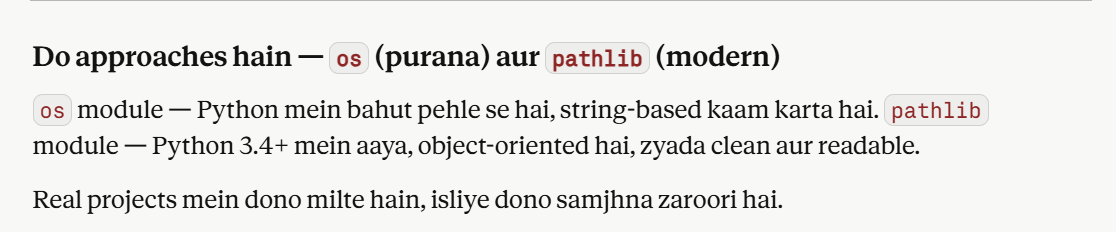

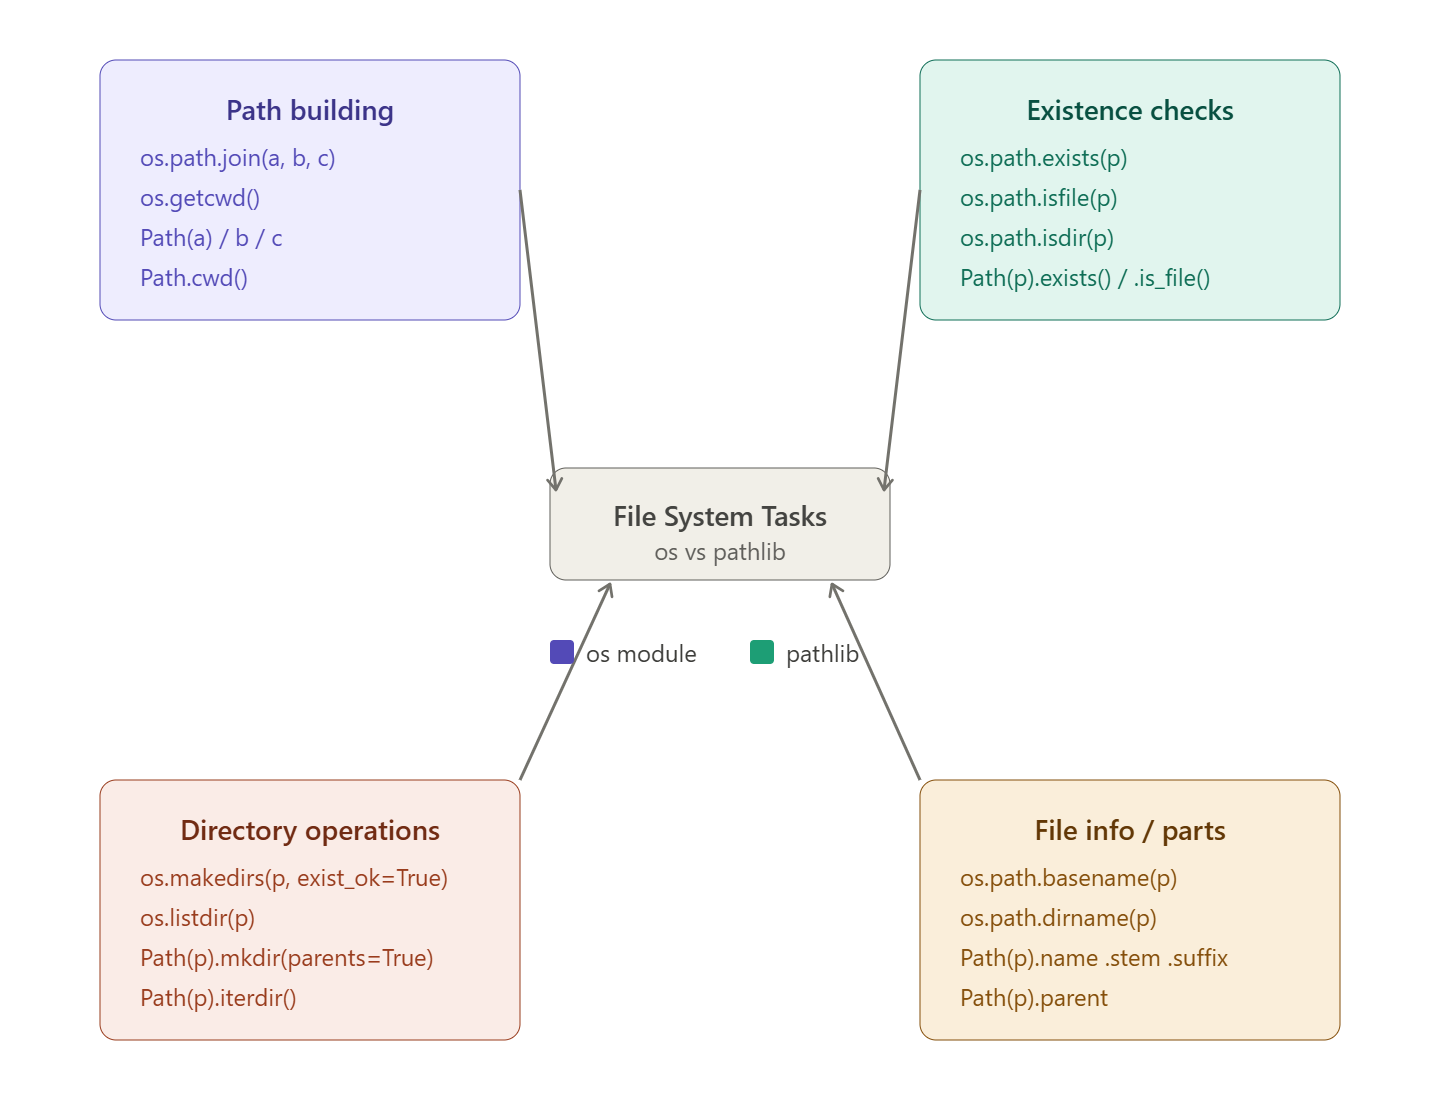

In [ ]:
# Category 1 — Path Building
# Ye sabse zyada use hota hai. Kabhi bhi path manually string se mat banao.

import os
from pathlib import Path
path='artifacts'+'/'+'model.pkl'
print(path)
path=os.path.join('artifacts','model.pkl')
print(path)

artifacts/model.pkl
artifacts\model.pkl


In [4]:
# Nested paths bhi easily
path = Path("artifacts") / "models" / "v1" / "model.pkl"
print(path)

artifacts\models\v1\model.pkl


In [5]:
# Current working directory — project root kahan hai
print(os.getcwd())      # "/home/user/mlprojecthindi"
print(Path.cwd())

c:\Users\WIN 10\Desktop\E2EDSProjectKN
c:\Users\WIN 10\Desktop\E2EDSProjectKN


Category 2 — Existence Checks
File ya folder exist karta hai ya nahi — ye check karna bahut zaroori hai production code mein.

In [6]:
import os
from pathlib import Path

path = "artifacts/model.pkl"

# os way
os.path.exists(path)   # True/False — file ya folder dono ke liye
os.path.isfile(path)   # True sirf agar file ho
os.path.isdir(path)    # True sirf agar folder ho

# pathlib way — same kaam, alag syntax
Path(path).exists()
Path(path).is_file()
Path(path).is_dir()

# Real use case — model load karne se pehle check karo
model_path = Path("artifacts/model.pkl")

if model_path.exists():
    pass
else:
    raise FileNotFoundError(f"Model nahi mila: {model_path}")

Category 3 — Directory Operations ⬅ ML mein sabse important
Ye sabse zyada ML projects mein use hota hai. Artifacts folder, logs folder — ye sab banane padta hai code se automatically.

In [9]:
import os
from pathlib import Path

# ─── os.makedirs ───────────────────────────────────────────
# Ek ya zyada nested folders banao
os.makedirs("artifacts/models/v1", exist_ok=True)
# exist_ok=True matlab: agar folder pehle se hai toh error mat do

# exist_ok=False (default) — agar folder hai toh error aayega
os.makedirs("artifacts")  # ❌ agar pehle se hai toh: FileExistsError

# ─── pathlib mkdir ─────────────────────────────────────────
Path("artifacts/models/v1").mkdir(parents=True, exist_ok=True)
# parents=True  → nested folders bhi banao (makedirs jaisa)
# exist_ok=True → pehle se ho toh ignore karo

# ─── Folder ke andar kya hai dekhna ────────────────────────
os.listdir("artifacts")
# → ['model.pkl', 'train.csv', 'test.csv', 'preprocessor.pkl']

# pathlib way — zyada powerful, generator deta hai
for item in Path("artifacts").iterdir():
    print(item)
# → PosixPath('artifacts/model.pkl')
# → PosixPath('artifacts/train.csv') ...

# Sirf files chahiye, folders nahi
files = [f for f in Path("artifacts").iterdir() if f.is_file()]

# ─── Krish ke project ka exact pattern ─────────────────────
# data_ingestion.py mein ye hota hai:

@dataclass
class DataIngestionConfig:
    train_data_path: str = os.path.join("artifacts", "train.csv")
    test_data_path: str  = os.path.join("artifacts", "test.csv")
    raw_data_path: str   = os.path.join("artifacts", "data.csv")

# Aur initiation mein:
os.makedirs(os.path.dirname(self.config.train_data_path), exist_ok=True)
# os.path.dirname(...) → "artifacts"  (sirf folder part)
# makedirs us folder ko banata hai agar nahi hai

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'artifacts'

In [10]:
l=os.listdir("artifacts")
# → ['model.pkl', 'train.csv', 'test.csv', 'preprocessor.pkl']
print(l)

['.gitignore', 'model.pkl', 'models', 'preprocessor.pkl', 'raw.csv.dvc', 'test.csv', 'train.csv']


Category 4 — File Info / Parts
Kisi bhi path ko uske parts mein todna — naam, extension, parent folder.

In [ ]:
from pathlib import Path
import os

path = "/home/user/mlproject/artifacts/model.pkl"

# ─── os way ────────────────────────────────────────────────
os.path.basename(path)    # "model.pkl"       ← sirf file naam
os.path.dirname(path)     # "/home/user/mlproject/artifacts"  ← sirf folder
os.path.splitext("model.pkl")  # ("model", ".pkl") ← naam aur extension alag

# ─── pathlib way — zyada clean ─────────────────────────────
p = Path(path)

p.name      # "model.pkl"         ← file naam with extension
p.stem      # "model"             ← sirf naam, bina extension
p.suffix    # ".pkl"              ← sirf extension
p.suffixes  # ['.tar', '.gz']     ← multiple extensions ke liye
p.parent    # PosixPath('/home/user/mlproject/artifacts')
p.parts     # ('/', 'home', 'user', 'mlproject', 'artifacts', 'model.pkl')

# ─── Real use case ─────────────────────────────────────────
# Naya path banana existing path se
old_path = Path("artifacts/model_v1.pkl")
new_path = old_path.parent / (old_path.stem + "_v2" + old_path.suffix)
print(new_path)  # artifacts/model_v1_v2.pkl

# Extension badalna
csv_path = Path("artifacts/data.csv")
pkl_path = csv_path.with_suffix(".pkl")
print(pkl_path)  # artifacts/data.pkl